Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       0.99      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



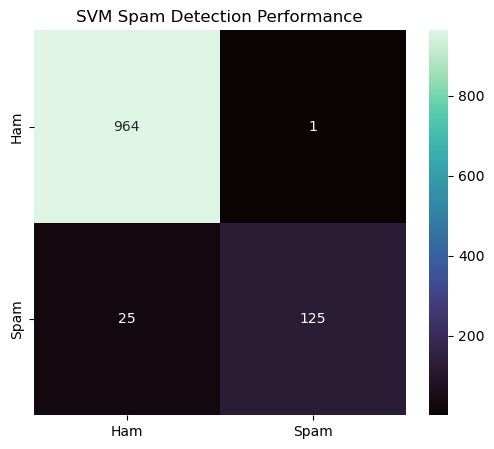

Sample Result: Ham


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean
data = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
data.columns = ['label', 'message']
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# TF-IDF with slight tweak: including bigrams (ngram_range) to catch phrases
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)
X = vectorizer.fit_transform(data['message'])
y = data['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM - switched to 'rbf' kernel for non-linear boundaries
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='mako',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("SVM Spam Detection Performance")
plt.show()

sample_msg = ["CONGRATULATIONS! You've won a $1000 Walmart gift card. Click here now!"]
sample_vec = vectorizer.transform(sample_msg)
prediction = "Spam" if model.predict(sample_vec)[0] == 1 else "Ham"
print(f"Sample Result: {prediction}")